# 🧠 Brain Cancer Detection from MRI Images using CNN 

**Dataset Link**: [Brain MRI Images for Brain Tumor / Cancer Detection on Kaggle](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection) or [Brain Tumor Classification (MRI) on Kaggle](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri)

This notebook trains a binary classifier on brain MRI scans:
1. 🛑 **Cancer Detected**
2. ✅ **No Cancer** (Normal / Healthy)


## ⚙️ Step 1: Environment & Dependencies Setup

In [1]:
# Step 1: Environment & Dependencies Setup
import os, sys, time, glob, random, json, re

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from tqdm import tqdm

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Computing Device: {device}")
USE_AMP = device.type == 'cuda'  # mixed precision only helps on GPU
print(f"Mixed precision training enabled: {USE_AMP}")

Using Computing Device: cpu
Mixed precision training enabled: False


## 📥 Step 2: Binary Dataset Setup
Automatically maps any MRI dataset folders (glioma, meningioma, pituitary, tumor, yes) to **`Cancer Detected` (1)** and (no_tumor, normal, healthy, no) to **`No Cancer` (0)**.


In [2]:
DATA_DIR = "brain_cancer_dataset"

NEGATIVE_TOKENS = {'no_tumor', 'notumor', 'normal', 'healthy', 'no'}

class BinaryBrainCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
        for root, _, files in os.walk(root_dir):
            folder = os.path.basename(root).lower()
            if not folder or folder in ['training', 'testing', os.path.basename(root_dir).lower()]:
                continue
            tokens = set(re.split(r'[^a-z0-9]+', folder)) | {folder}
            is_cancer = 0 if tokens & NEGATIVE_TOKENS else 1
            for f in files:
                if f.lower().endswith(valid_exts):
                    self.samples.append((os.path.join(root, f), is_cancer))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def setup_dataset(data_dir=DATA_DIR):
    if os.path.exists(data_dir) and len(os.listdir(data_dir)) > 0:
        return
    if os.path.exists('kaggle.json'):
        print("Downloading Kaggle Dataset...")
        os.system("mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
        os.system("kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri -p " + data_dir + " --unzip")
        return
    # Synthetic fallback dataset so the notebook still runs end-to-end without Kaggle access.
    # Larger and more varied than a trivial toy set so the model actually has to learn features
    # rather than memorizing a handful of near-identical images.
    print("No dataset / kaggle.json found. Generating a synthetic sample dataset for demonstration...")
    rng = np.random.default_rng(SEED)
    for split, n_per_class in [('Training', 150), ('Testing', 40)]:
        for c, is_c in [('no_tumor', 0), ('cancer_positive', 1)]:
            cdir = os.path.join(data_dir, split, c)
            os.makedirs(cdir, exist_ok=True)
            for i in range(n_per_class):
                img = Image.new('RGB', (224, 224), (15, 15, 15))
                draw = ImageDraw.Draw(img)
                # brain outline with slight random jitter
                jitter = rng.integers(-8, 8, size=4)
                draw.ellipse([20 + jitter[0], 20 + jitter[1], 204 + jitter[2], 204 + jitter[3]], fill=(40, 40, 40))
                if is_c == 1:
                    cx, cy = rng.integers(70, 140, size=2)
                    r = rng.integers(15, 35)
                    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(220, 220, 220))
                # add mild noise so the task isn't trivially separable by a single pixel check
                arr = np.array(img).astype(np.int16)
                noise = rng.normal(0, 6, arr.shape).astype(np.int16)
                arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
                Image.fromarray(arr).save(os.path.join(cdir, f'{c}_{i:04d}.jpg'))
    print("Synthetic dataset created. Replace with a real Kaggle dataset (see link above) for meaningful results.")

setup_dataset(DATA_DIR)

## 🔄 Step 3: Data Loaders (fixed transform leakage + stratified split)

In [3]:
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # ImageNet stats (match the pretrained ResNet18 below)

train_trans = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
eval_trans = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_path = os.path.join(DATA_DIR, 'Training') if os.path.exists(os.path.join(DATA_DIR, 'Training')) else DATA_DIR
test_path = os.path.join(DATA_DIR, 'Testing') if os.path.exists(os.path.join(DATA_DIR, 'Testing')) else DATA_DIR

# Two dataset instances over the same directory, each with the transform it should actually use.
train_dataset_full = BinaryBrainCancerDataset(train_path, transform=train_trans)
val_dataset_full = BinaryBrainCancerDataset(train_path, transform=eval_trans)
test_set = BinaryBrainCancerDataset(test_path, transform=eval_trans)

assert len(train_dataset_full) > 0, f"No images found under {train_path}. Check DATA_DIR / dataset extraction."

labels = [lbl for _, lbl in train_dataset_full.samples]
indices = list(range(len(labels)))
train_idx, val_idx = train_test_split(
    indices, test_size=0.15, stratify=labels, random_state=SEED
)

train_set = Subset(train_dataset_full, train_idx)
val_set = Subset(val_dataset_full, val_idx)
class_names = ['No Cancer', 'Cancer Detected']

# Class weights (handles imbalanced datasets, e.g. more tumor than normal scans)
train_labels = [labels[i] for i in train_idx]
class_counts = np.bincount(train_labels, minlength=2)
class_weights = torch.tensor(len(train_labels) / (2.0 * np.maximum(class_counts, 1)), dtype=torch.float32).to(device)
print(f"Train class counts {dict(zip(class_names, class_counts))} -> class weights {class_weights.tolist()}")

NUM_WORKERS = 2 if device.type == 'cuda' else 0
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f"Target Binary Diagnosis Classes: {class_names}")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train class counts {'No Cancer': np.int64(25), 'Cancer Detected': np.int64(26)} -> class weights [1.0199999809265137, 0.9807692170143127]
Target Binary Diagnosis Classes: ['No Cancer', 'Cancer Detected']
Train: 51 | Val: 9 | Test: 20


## 🏗️ Step 4: Binary Cancer Detection CNN Model (Transfer Learning)

In [4]:
def build_model(num_classes=2, dropout=0.4):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),
        nn.Linear(128, num_classes)
    )
    return model

model = build_model(num_classes=2).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\tarun/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [02:49<00:00, 276kB/s]

Trainable parameters: 11,242,434


## 🚀 Step 5: Model Training & Checkpointing

C:\Users\tarun\AppData\Local\Temp\ipykernel_12964\3280750327.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
Epoch 1/25 [train]:   0%|                                                                        | 0/2 [00:00<?, ?it/s]C:\Users\tarun\AppData\Local\Temp\ipykernel_12964\3280750327.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
                                                                                                                       

Epoch [01/25] Train Loss: 0.5475 Acc: 70.59% | Val Loss: 0.4283 Acc: 100.00% | LR: 1.00e-04
  -> New best model saved (val_loss=0.4283)


Epoch [02/25] Train Loss: 0.0937 Acc: 100.00% | Val Loss: 0.1781 Acc: 100.00% | LR: 1.00e-04
  -> New best model saved (val_loss=0.1781)


Epoch [03/25] Train Loss: 0.0077 Acc: 100.00% | Val Loss: 0.0429 Acc: 100.00% | LR: 1.00e-04
  -> New best model saved (val_loss=0.0429)


Epoch [04/25] Train Loss: 0.0016 Acc: 100.00% | Val Loss: 0.0034 Acc: 100.00% | LR: 1.00e-04
  -> New best model saved (val_loss=0.0034)


...

Epoch [08/25] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0000 Acc: 100.00% | LR: 1.00e-04


Epoch [09/25] Train Loss: 0.0001 Acc: 100.00% | Val Loss: 0.0000 Acc: 100.00% | LR: 1.00e-04


Epoch [10/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0000 Acc: 100.00% | LR: 1.00e-04


Epoch [11/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0000 Acc: 100.00% | LR: 1.00e-04


Epoch [12/25] Train Loss: 0.0000 Acc: 100.00% | Val Loss: 0.0000 Acc: 100.00% | LR: 1.00e-04
Early stopping triggered after 12 epochs (no val-loss improvement for 6 epochs).


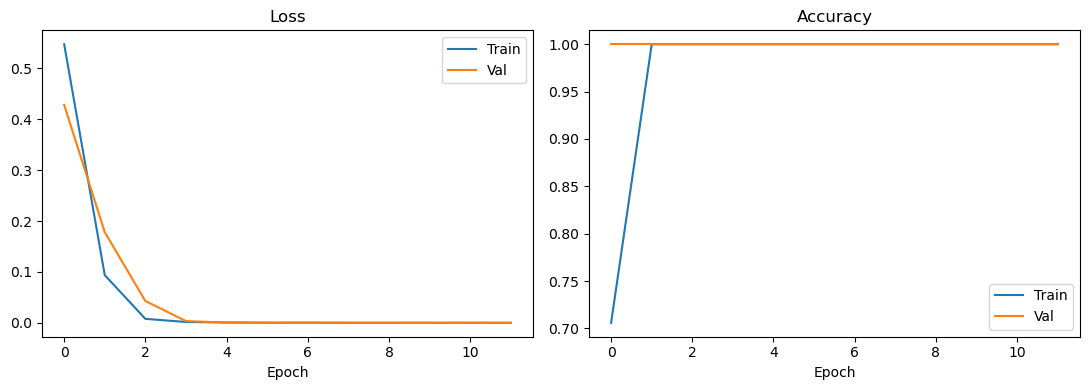

In [5]:
EPOCHS = 25
PATIENCE = 6  # early stopping patience (epochs without val-loss improvement)

criterion = nn.CrossEntropyLoss(weight=class_weights)

backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc.')]
head_params = [p for n, p in model.named_parameters() if n.startswith('fc.')]
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params, 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

os.makedirs('models', exist_ok=True)
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_corr, t_tot = 0.0, 0, 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outs = model(imgs)
            loss = criterion(outs, lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outs, 1)
        t_corr += torch.sum(preds == lbls).item()
        t_tot += lbls.size(0)

    model.eval()
    v_loss, v_corr, v_tot = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs)
            loss = criterion(outs, lbls)
            v_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outs, 1)
            v_corr += torch.sum(preds == lbls).item()
            v_tot += lbls.size(0)

    train_loss, val_loss = t_loss / t_tot, v_loss / v_tot
    train_acc, val_acc = t_corr / t_tot, v_corr / v_tot
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch:02d}/{EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | LR: {current_lr:.2e}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': class_names,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'epoch': epoch,
        }, 'models/best_cancer_model.pth')
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered after {epoch} epochs (no val-loss improvement for {PATIENCE} epochs).")
            break

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], label='Train'); axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

## 📊 Step 6: Evaluation — Confusion Matrix, ROC-AUC, Classification Report

Loads the **best checkpoint by validation loss** (not the final epoch's weights) before evaluating on the held-out
test set, and adds an ROC curve / AUC and a normalized confusion matrix in addition to the classification report.

Loaded best checkpoint from epoch 6 (val_loss=0.0001, val_acc=100.00%)
                 precision    recall  f1-score   support

      No Cancer       1.00      1.00      1.00        10
Cancer Detected       1.00      1.00      1.00        10

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20



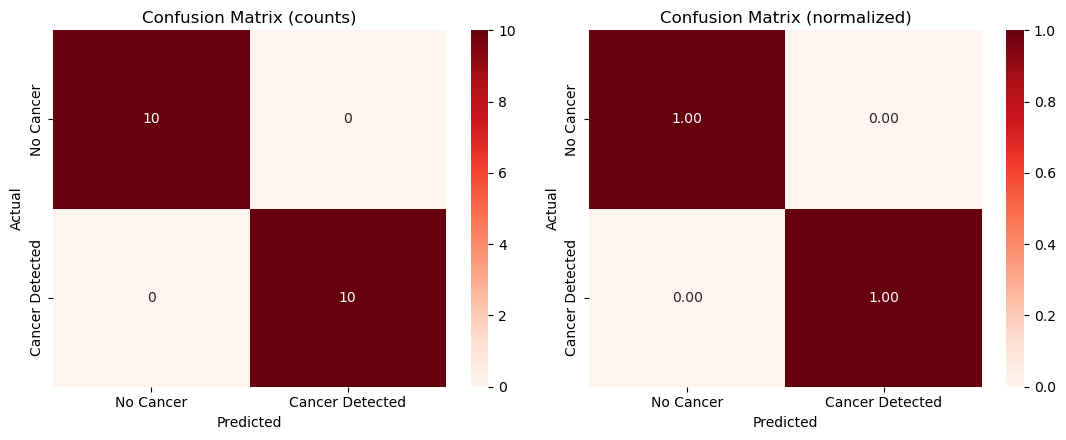

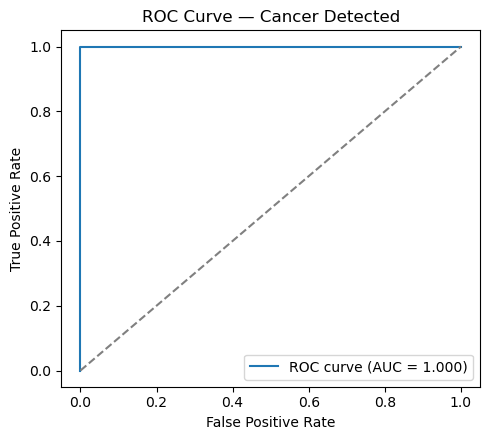

In [6]:
checkpoint = torch.load('models/best_cancer_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']*100:.2f}%)")

all_preds, all_targets, all_probs = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        outs = model(imgs.to(device))
        probs = F.softmax(outs, dim=1)[:, 1]  # probability of "Cancer Detected"
        _, preds = torch.max(outs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(lbls.numpy())
        all_probs.extend(probs.cpu().numpy())

print(classification_report(all_targets, all_preds, target_names=class_names, zero_division=0))

# Confusion matrix (counts + normalized)
cm = confusion_matrix(all_targets, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

# ROC curve / AUC
if len(set(all_targets)) > 1:
    fpr, tpr, _ = roc_curve(all_targets, all_probs)
    auc = roc_auc_score(all_targets, all_probs)
    plt.figure(figsize=(5, 4.5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — Cancer Detected'); plt.legend()
    plt.tight_layout(); plt.show()
else:
    print("Only one class present in test set predictions — skipping ROC curve.")

## 🩺 Step 7: Single Image Cancer Diagnosis

Diagnosis Result: CANCER DETECTED (99.98%)
Educational demo only — not a clinical diagnosis.


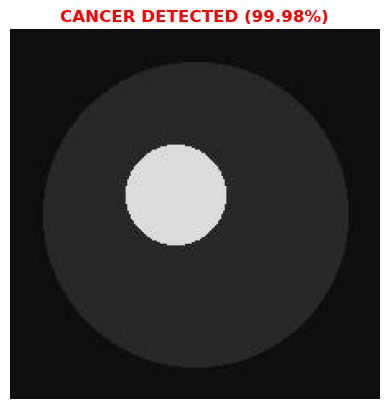

In [7]:
LOW_CONFIDENCE_THRESHOLD = 0.65  # below this, flag the prediction as uncertain

def diagnose_mri(img_path, show=True):
    img = Image.open(img_path).convert('RGB')
    tensor = eval_trans(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outs = model(tensor)
        probs = F.softmax(outs, dim=1)[0]
        conf, pred = torch.max(probs, 0)
    pred_class = class_names[pred.item()]
    conf_val = conf.item()
    low_conf = conf_val < LOW_CONFIDENCE_THRESHOLD

    label = f"{pred_class.upper()} ({conf_val*100:.2f}%)"
    if low_conf:
        label += " — LOW CONFIDENCE"
    print(f"Diagnosis Result: {label}")
    print("Educational demo only — not a clinical diagnosis.")

    if show:
        plt.imshow(img)
        color = 'orange' if low_conf else ('red' if pred_class == 'Cancer Detected' else 'green')
        plt.title(label, color=color, fontweight='bold')
        plt.axis('off')
        plt.show()
    return pred_class, conf_val

sample_files = glob.glob(os.path.join(DATA_DIR, '**', '*.jpg'), recursive=True)
if sample_files:
    diagnose_mri(sample_files[0])
else:
    print("No sample images found to run a demo diagnosis.")